# Expressing DeepSeek-V4.1-Flash

This notebook writes DeepSeek-V4.1-Flash, restricted to a prompt of text, as one algebraic expression and draws it one part at a time beside the released code that computes each part. It then states the number format in which the released code holds every array, and its last cell writes an interactive page that holds the model at those formats and the same model in the real numbers.

*Written by Claude Opus 5.5 (1M context) at effort 40, 2026-09-27.*

In [1]:
import dataclasses

from IPython.display import Markdown, display

import advanced_axis_dynamics.algebra.slide_causal_reads_backwards as slide_causal_reads_backwards
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.display.sota_figures as figures
import notebooks.sota.DeepSeekV41Flash.integrated_explanations as integrated_explanations
import notebooks.sota.DeepSeekV41Flash.quantised_text_only_model as quantised_text_only_model
import notebooks.sota.DeepSeekV41Flash.text_only_model as text_only_model
import notebooks.website.website_output as website_output
from notebooks.sota.DeepSeekV41Flash.block_titles_and_descriptions import TEXT as text

FIGURES = integrated_explanations.with_text_only_explanation_tables(
    figures.DiagramSettings(
        mode=figures.DiagramMode.INLINE,
        dark_mode=notebook_diagrams.ColorMode.LIGHT,
        tape=figures.TapePresentation.ABSORBED,
        axis_sizes=figures.AxisSizes.SUBSCRIPT,
        assigned_sizes=text_only_model.released_assigned_sizes(),
        axis_label_font_size=0.8,
        block_recycling=figures.BlockRecycling.RECYCLED,
        advanced_display=figures.AdvancedDisplay.LEGEND,
        expanded_parameters=figures.ExpandedParameters.WEIGHT_ARRAYS,
        clean_quantisation_labels=False,
        title='DeepSeek-V4.1-Flash (Text Only, Reference Implementation)'))
QUANTISED_FIGURES = quantised_text_only_model.with_quantised_explanation_tables(
    dataclasses.replace(
        FIGURES, assigned_sizes=quantised_text_only_model.released_assigned_sizes(),
        title='DeepSeek-V4.1-Flash (Text Only, Quantised, Reference Implementation)'))
UNQUANTISED_PAGE = dataclasses.replace(
    FIGURES, mode=figures.DiagramMode.HTML, dark_mode=None, width=1600,
    sub_blocks=figures.SubBlocks.NO_BODIES, display_mode=figures.DisplayMode.FAST,
    advanced_display=figures.AdvancedDisplay.INTERACTIVE,
    page_directory=website_output.MODERN_PAGES)
QUANTISED_PAGE = dataclasses.replace(
    QUANTISED_FIGURES, mode=figures.DiagramMode.HTML, dark_mode=None, width=2000,
    sub_blocks=figures.SubBlocks.NO_BODIES, display_mode=figures.DisplayMode.FAST,
    advanced_display=figures.AdvancedDisplay.INTERACTIVE,
    page_directory=website_output.MODERN_PAGES)

UNQUANTISED = slide_causal_reads_backwards.slide_causal_reads_backwards(
    text_only_model.v41_flash_text_only)
QUANTISED = slide_causal_reads_backwards.slide_causal_reads_backwards(
    quantised_text_only_model.v41_flash_text_only_quantised)

figures.forget_drawn_blocks()

## Reading the figures

A figure is a neural circuit diagram of one expression. Every wire is an array, and the label on a wire names the axes of the array with the released size of each axis written as its subscript. An operator is a shape drawn across its operands and its results. A wire that passes through an operator carries an axis the operator is broadcast over, and the operator computes the same function separately at every index of that axis. A wire that ends at an operator carries an axis the operator consumes, and the function of the operator reads every index of that axis together.

A block is a titled box around a part of the expression. A block whose repetition is greater than one is a loop, and the number it carries is the number of times the loop runs its body. A box drawn with a short bold name stands for a block. The body of that block is drawn beside the first figure that holds the box, and later figures draw the box alone.

A value computed by one layer and read by a later layer travels on a tape. The layer that computes the value ends in a drop onto a named slot of the tape, and every layer that reads the value begins with a grab from the same slot. The released code keeps such values in one runtime object shared by every layer, and a tape slot is one field of that object ([L1166-L1176](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1166-L1176)). Every slot the model writes, it also reads.

No size appears in the expression. Each axis carries a free symbol, and the released sizes are written onto the labels when a figure is drawn. The table gives the released size of every axis. The number of tokens in the prompt is left free, so the token axis is sized by the number of compressed entries of the encoder, which is free as well.

| axis | released size | what it indexes |
| --- | --- | --- |
| `x`, `v` | $\lvert a \rvert \lvert b \rvert$, 129280 | the tokens of the prompt, and the vocabulary |
| `m`, `n` | 5120, 4 | the residual width, and the four residual streams |
| `h`, `c` | 64, 512 | the query heads, and the width of the shared key-value latent |
| `q`, `o`, `g`, `j` | 1280, 1024, 8, 8 | the query low rank, the output low rank, the output head groups, and the heads within a group |
| `w`, `a` | 128, 2 | a slot of the sliding window, and a token within a compression group |
| `b`, `B` | free, $\lvert x \rvert$ | the compressed entries of the encoder, and those of the decoder |
| `r` | the size of the entry axis it counts over | an entry counted back from the newest entry a query has reached |
| `u`, `P`, `p`, `C` | 8, free, 2048, 16384 | a distance within a candidate block, the blocks, the kept blocks, and the candidate distances |
| `s`, `k` | 512, 6 | a slot of a Top-512 selection, and a slot of the six experts chosen for a token |
| `i`, `d` | 32, 128 | the indexer heads, and the width of one |
| `e`, `f` | 384, 2304 | the routed experts, and the hidden width of one expert |
| `t`, `z` | 32, $2 \lvert t \rvert$ | the rotated pairs of a latent, and the rotated channels |
| `L`, `G`, `K`, `D` | 4, 3, 8, 256 | the identifiers one n-gram hash reads, the n-gram orders, the hash heads, and the width of one Engram row |
| `E`, `y` | 32, 16 | the scale groups of a compressed entry, and the channels of one group |
| `\hat{E}`, `\tilde{E}`, `\hat{y}` | 4, 16, 32 | the scale groups of an indexer key or query, the scale groups of a window latent, and the channels of one of those groups |

Beside each figure stands a legend with one row per named axis. A row gives the axis, the integer of its size, and the name the axis and its size take in generated code.

An axis written with a bar, such as `w|x`, holds a value at some of its positions and nothing at the others, and the axis after the bar decides which. The window slot $j_{w}$ of query $i_{x}$ holds a value where $i_{x} - j_{w} \geq 0$. A position holding nothing holds the universal unit, which every sum, maximum and contraction ignores and every elementwise map preserves.

Every figure draws the model in its CausalSlide form. A causal read is a view that reads, for each token, a token at or before it, as the sliding window reads token $i_{x} - j_{w}$ at slot $j_{w}$ of query $i_{x}$. An operation that computes the same function at every token gives the same result whether the read stands before it or after it, because it computes at the token the read names what it would have computed there anyway. Each causal read is therefore drawn as far back as it moves, at the copy of the array whose other branches read it whole. The form shows which operations run once per token and which run once per token and slot. The model is built with each read where the released code applies it, and the form is applied for the figures and the page. The layers and every wire between them are the same in both forms, and every read that moves stands inside a box.

## The released model and the restriction to text

DeepSeek-V4.1-Flash was released on 2026-09-10 under the MIT licence ([model card](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash), [release note](https://api-docs.deepseek.com/news/news260910/)). Its backbone holds 552B parameters, and its two Engram modules, which hash the identifiers of recent tokens into large lookup tables, hold a further 196B. Its context is 1M tokens.

The released code is the `inference` folder of the repository `deepseek-ai/DeepSeek-V4.1-Flash` on Hugging Face, read at commit `dba1be0a40aa` on 2026-09-11. No mirror of the repository existed under the `deepseek-ai` organisation on GitHub on that date. Every link in this notebook is pinned to that commit, so a line number stays valid after the repository moves on. Where the technical report and the code disagree, the expression follows the code.

The released model reads an image beside the prompt and drafts five further tokens with DSpark after the backbone has produced one. The expression reads a prompt of text alone, so it holds neither the image pathway nor DSpark. Three smaller differences follow from the absence of an image. The model writes no tape slot for the modality of a token, the router of every mixture sublayer adds one correction bias, and the gate of Engram has no factor for the modality.

The expression is the forward pass over a whole prompt. It reads the identifier of every token and returns the probability of every vocabulary entry at every position, and it keeps no cache from one call to the next. The three caches of the released code appear in it as the rounding the released code applies to the values stored in them.

## The embedding and the four residual streams

The model reads one array, the identifiers of the prompt's tokens, and returns one array, the probability of every vocabulary entry at every position. The identifiers are looked up in a table of 129,280 rows of 5,120 channels, and the lookup gives one hidden state per token ([L174](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L174), [L1253](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1253)).

A view then repeats the hidden state into four streams, which is the released `repeat` over `hc_mult` ([L1257-L1258](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1257-L1258)). Each sublayer collapses the four streams into one hidden state under a vector of four coefficients and writes its result back into all four, and the next section states that write. The first sublayer has no sublayer before it to predict its coefficients, so its collapse vector is fixed at a one-hot on the first stream, built by `make_identity_pre_mix` in the released code ([L1159-L1163](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1159-L1163)). The expression writes the one-hot as a covariant view with no operands. A covariant view writes each position of its operand onto the position of its result named by its reindexing, and a position that no write reaches holds the universal unit.

The identifiers are copied a second time and dropped onto the tape slot $\mathrm{ids}$, and the two Engram modules grab that slot ([L1241-L1243](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1241-L1243), [L1267](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1267)). Engram hashes the identifiers of recent tokens, so the identifiers have to reach layers 1 and 14.

The head of the model. The token identifiers are copied, one copy is embedded and the other is dropped onto the tape slot ids, the hidden state is repeated into the four residual streams, and the collapse vector of the first sublayer is a fixed one-hot.


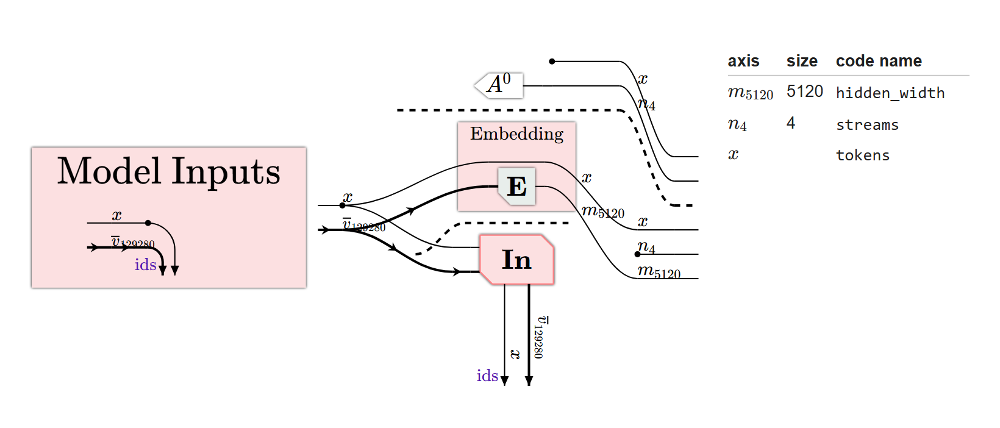

In [2]:
head = quantised_text_only_model.part_before_the_layers(UNQUANTISED)

await figures.show(
    head,
    'The head of the model. The token identifiers are copied, one copy is embedded and '
    'the other is dropped onto the tape slot ids, the hidden state is repeated into the '
    'four residual streams, and the collapse vector of the first sublayer is a fixed '
    'one-hot.',
    width=1200, settings=FIGURES)

## The mixing coefficients of the four streams

A plain residual stream adds the result of every sublayer to one running hidden state. DeepSeek-V4.1-Flash carries four streams, and the released code mixes them by a manifold-constrained hyper-connection that the release calls Single-Pass mHC. Each sublayer reads three sets of coefficients predicted from the four streams of its own token. The collapse vector holds four numbers, the output vector holds four numbers, and the combine matrix holds four by four. The input of the sublayer is the four streams summed under the collapse vector, $\sum_{i_{n} \in n} A[i_{n}]\, s[i_{n}, i_{m}]$ for the streams $s$ and the collapse vector $A$. The sublayer then writes back the output vector times its result, added to the combine matrix applied to the four streams it received.

The collapse vector used by a sublayer is the vector predicted by the sublayer before it. The prediction and the input mixing therefore do not depend on each other, and the released kernel reads the residual once per sublayer. The name Single-Pass records that single read. The collapse vector travels beside the residual as a second wire through every block of the model.

Three linear maps read the RMS-normalised streams of a token. $H_{0}$ gives the four numbers of the collapse vector, $H_{1}$ the four of the output vector, and $H_{2}$ the sixteen of the combine matrix. The released code holds the three as one weight of 24 rows and cuts the 24 results into 4, 4 and 16 ([L907-L915](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L907-L915)). A linear map followed by a slice of its results is the linear map whose weight is that slice of the rows, so the expression writes three maps and no slice. The collapse vector takes a sigmoid plus $\varepsilon_{\mathrm{hc}}$, and the output vector takes twice a sigmoid ([kernel.py L427](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L427)).

The combine matrix is made doubly stochastic by Sinkhorn normalisation, which divides each row by its sum and each column by its sum in turn. The released kernel runs twenty rounds, the `hc_sinkhorn_iters` of the released configuration ([kernel.py L450](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L450), [kernel.py L465](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L465), [config.json L41](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/config.json#L41)). The first round takes the exponential of every entry, divides each row by its sum, adds $\varepsilon_{\mathrm{hc}}$ to every entry and divides each column by its sum ([kernel.py L436-L443](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L436-L443)). Each of the nineteen rounds after it divides every row and then every column by its sum, so the figure draws them as one block at repetition nineteen ([kernel.py L450-L458](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L450-L458)).

The prediction reads the four streams of one token alone, so it is one box computed once per token, and its body holds no token axis. The prediction is written once and composed at every sublayer.

The mixing coefficients of one token. Three linear maps read the RMS-normalised streams, the collapse vector takes a sigmoid, the output vector takes twice a sigmoid, and the first Sinkhorn round with the nineteen rounds after it makes the combine matrix doubly stochastic.


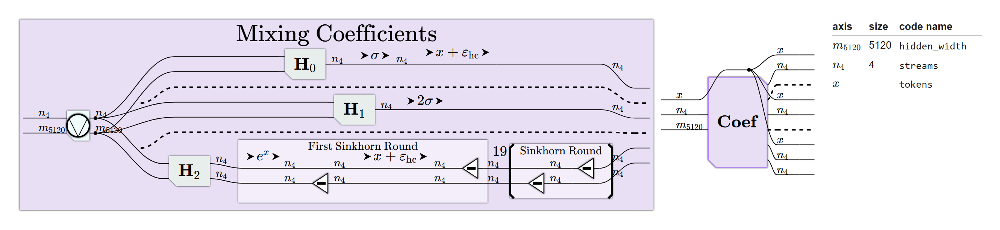

One layer, drawn with the body of every box left out. An attention sublayer and a mixture sublayer each collapse the four streams under the coefficients predicted by the sublayer before them and write their result back into all four.


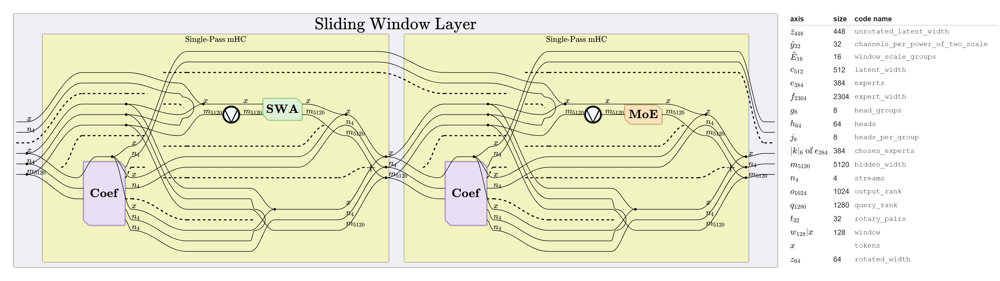

In [3]:
coefficients = quantised_text_only_model.part_named('Coef', UNQUANTISED)
one_layer = quantised_text_only_model.part_titled(text.WINDOW_LAYER_TITLE, UNQUANTISED)

await figures.show(
    coefficients,
    'The mixing coefficients of one token. Three linear maps read the RMS-normalised '
    'streams, the collapse vector takes a sigmoid, the output vector takes twice a '
    'sigmoid, and the first Sinkhorn round with the nineteen rounds after it makes the '
    'combine matrix doubly stochastic.',
    width=1600, settings=FIGURES)

await figures.show(
    one_layer,
    'One layer, drawn with the body of every box left out. An attention sublayer and a '
    'mixture sublayer each collapse the four streams under the coefficients predicted '
    'by the sublayer before them and write their result back into all four.',
    width=1600, sub_blocks=figures.SubBlocks.NO_BODIES, settings=FIGURES)

## The sliding-window attention

Layers 0 and 1 attend over the last 128 tokens alone. Each projects a 512-wide key-value latent from the hidden state of a token, normalises it, turns it by the rotary embedding of the next section and rounds it through the FP8 cache, and a view reads the latents of the last 128 tokens at the row $i_{x} - j_{w}$ ([L410-L424](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L410-L424), [L700-L720](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L700-L720)). Slot $j_{w}$ of query $i_{x}$ holds the token $j_{w}$ positions back, so slot 0 is the current token and no slot reads a later one. At a query earlier than position 127 the last slots name a negative token. A read outside an axis holds the universal unit, and every sum and contraction ignores it. The released code marks such a slot with $-1$, and its kernel gives the slot a zero key and a score of $-\infty$ ([kernel.py L362-L364](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L362-L364)).

In the CausalSlide the window view reads the hidden state the layer receives, at the copy that also feeds the query. The projection, the normalisation, the rotation and the FP8 round trip of the latent then run once per token and slot. The released code computes each latent once, when its token arrives, and keeps it in the window cache, and slot $j_{w}$ of query $i_{x}$ reads the latent of token $i_{x} - j_{w}$. The figure computes the latent of every slot from the hidden state that the slot reads, and the two give the same values.

One 512-wide latent serves all 64 query heads. The latents the attention core reads carry no head axis, so the score contraction broadcasts the 64 query heads against one latent per slot. The query is projected in two steps through a 1,280-wide low rank.

The attention core is one box computed once per head, and the model composes it at nine sites. It holds the contraction of the query against the latents of the slots, a scale of $\lvert c \rvert^{-1/2}$ on every score ([L651](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L651)), an exponential, a sum of the exponentials into a denominator, and the contraction of the exponentials against the latents. A learned logit per head, the attention sink, is added to the denominator and to nothing else, so a head whose scores are all small puts most of its weight on the sink ([L639](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L639), [kernel.py L392](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L392)).

The attention output leaves as 64 heads of 512 channels, and a grouped low-rank projection maps it back to the 5,120-wide residual. The 64 heads are cut into 8 groups of 8, each group's 4,096 values are mapped to a 1,024-wide rank of its own, and one final weight reads the eight ranks together. The released code writes the first map as `einsum("bsgd,grd->bsgr")` ([L787](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L787)). The expression writes it as a `Linear` producing the group and the rank, followed by a diagonal view that keeps the entries where the group produced by the weight and the group of the input agree. The projection is one box computed once per token.

The sliding-window attention of layers 0 and 1, with the body of each box beside it. The window reads the hidden state, and the latent of every slot is projected, normalised, turned at the position of its own token and rounded through the FP8 cache. The query passes through its low rank and is turned, the attention core runs over the 128 slots and the sink, the output is turned back, and the grouped low-rank projection returns the residual width.


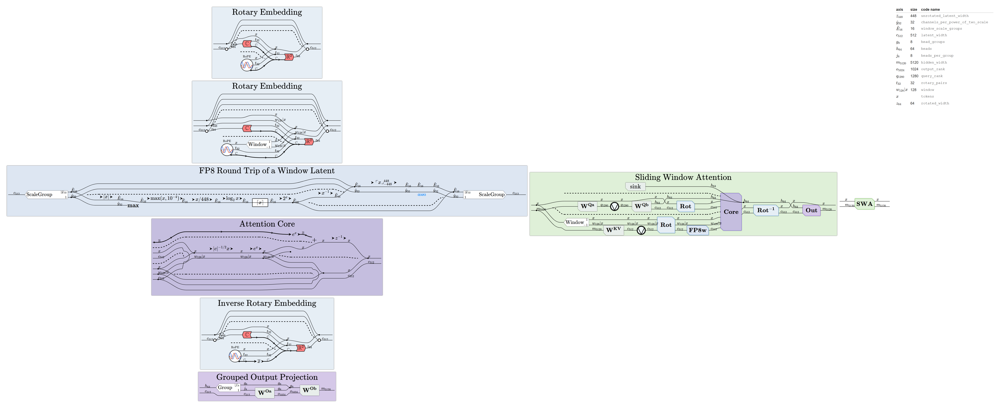

In [4]:
sliding_window = quantised_text_only_model.part_named('SWA', UNQUANTISED)

await figures.show(
    sliding_window,
    'The sliding-window attention of layers 0 and 1, with the body of each box beside '
    'it. The window reads the hidden state, and the latent of every slot is projected, '
    'normalised, turned at the position of its own token and rounded through the FP8 '
    'cache. The query passes through its low rank and is turned, the attention core runs '
    'over the 128 slots and the sink, the output is turned back, and the grouped '
    'low-rank projection returns the residual width.',
    width=2300, settings=FIGURES)

## The rotary embedding and its YaRN scaling

A rotary embedding turns part of every query and every key through an angle that grows with the position of its token, so that the score of a query against a key depends on the distance between the two tokens ([L368-L406](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L368-L406), [L771-L772](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L771-L772), [L705-L706](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L705-L706)). The released model turns the last 64 of the 512 channels of a latent and leaves the first 448 alone.

Each rotation is one box, and the body of the rotation below holds five steps. A deconcatenation cuts the channel axis into the 448 channels left alone and the 64 turned. A pairing reads the 64 channels as 32 complex numbers, with the first channel of a pair as the real part. A product multiplies each complex number by the entry of a table of turns for the position of the token and for the pair. An unpairing writes the pairs back as 64 channels, and a concatenation joins the two runs back onto the channel axis. The entry of the table at position $i_{x}$ and pair $i_{t}$ is $F[i_{x}, i_{t}] = e^{\mathrm{i}\, i_{x}\, \theta[i_{t}]}$ for the frequency $\theta[i_{t}] = \beta^{-i_{t}/\lvert t \rvert}$.

A Full layer turns five arrays. They are the query, the window latent, the compressed entries, and the keys and the query of the indexer. Every attention mode turns its output back through the angle of the query's own position ([L780-L781](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L780-L781)). Turning back multiplies by the conjugate of the same entry, because the conjugate of a complex number of length one turns through the same angle in the other direction. Where the window read has moved into a rotation, the rotation reads its table through the same window view, so the latent of each slot turns at the position of its own token.

Layers 0 and 1 hold no compressed entries and turn at the base $\beta_{0} = 10000$. Every other layer turns at the base $\beta = 160000$, with the frequencies of the slowly turning pairs lowered by YaRN so that a context longer than the training context produces angles that occurred in training. YaRN divides the frequency of a slow pair by $\kappa = 16$ and fades between the two ends of a ramp. The ramp is $r[i_{t}] = \ulcorner (i_{t} - \mathrm{lo}) / (\mathrm{hi} - \mathrm{lo}) \lrcorner$, the clamp of that ratio to the interval from 0 to 1, with $\mathrm{lo} = 15$ and $\mathrm{hi} = 25$. The frequency of pair $i_{t}$ is then $\theta'[i_{t}] = \beta^{-i_{t}/\lvert t \rvert}\, (1 - r[i_{t}] + r[i_{t}]/\kappa)$. Each table writes its own name above its circle, RoPE or YaRN.

The rotary embedding of the query in a sliding-window layer, drawn as its box beside its body. The channels are deconcatenated and paired, the pairs are multiplied by the table of turns, drawn as a circle named RoPE, and the pairs are unpaired and concatenated back onto the channel axis c.


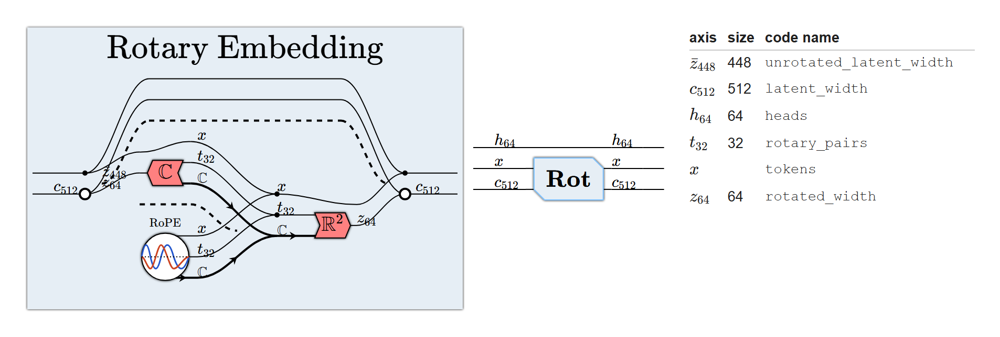

In [5]:
rotation = quantised_text_only_model.part_named('Rot', UNQUANTISED)

await figures.show(
    rotation,
    'The rotary embedding of the query in a sliding-window layer, drawn as its box beside '
    'its body. The channels are deconcatenated and paired, the pairs are multiplied by '
    'the table of turns, drawn as a circle named RoPE, and the pairs are unpaired and '
    'concatenated back onto the channel axis c.',
    width=1400, sub_blocks=figures.SubBlocks.EVERY_BODY, settings=FIGURES)

## The token compressors

Beside its sliding window, every layer from 2 upward attends over compressed entries chosen from the whole context. A compressed entry stands for a group of consecutive tokens, and a compressor makes one. The encoder groups tokens two at a time and the decoder one at a time. The groups do not overlap and are anchored at absolute positions, so the membership of an entry never changes as the sequence grows. The model compresses at three sites.

Two projections read the hidden state, one giving a 512-wide value per token and one giving a 512-wide logit ([L429](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L429), [L475](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L475)). A softmax over the two positions of a group, taken separately for each of the 512 channels, turns the logits into weights that are positive and sum to one. One contraction against those weights and an RMSNorm finish the entry. At ratio one a group holds one position and the softmax over one position is one, so the compressor of the decoder is the projection and the normalisation alone.

The decoder holds one compressor, in its first layer, and it reads the hidden state produced by the last layer of the encoder. The entries it makes are dropped onto the tape slot $\mathrm{ckv}_{B}$ at layer 20, and every later decoder layer grabs them.

The compressor of the encoder. A group view reads two tokens per entry and is copied into a value projection and a gate projection, the softmax over the group runs per channel, and the contraction and the RMSNorm finish the entry.


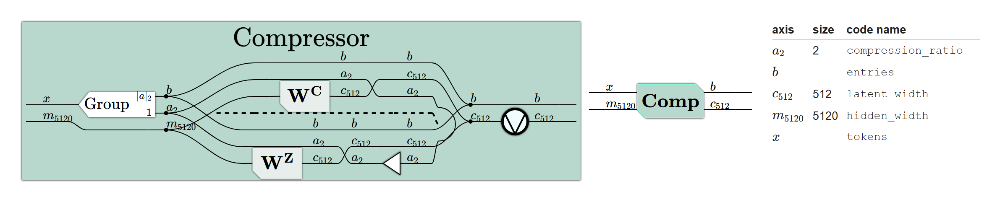

In [6]:
compressor = quantised_text_only_model.part_named('Comp', UNQUANTISED)

await figures.show(
    compressor,
    'The compressor of the encoder. A group view reads two tokens per entry and is copied '
    'into a value projection and a gate projection, the softmax over the group runs per '
    'channel, and the contraction and the RMSNorm finish the entry.',
    width=1400, settings=FIGURES)

## The FP4 and FP8 rounding of the three caches

The cache of compressed entries is the largest array held in memory while a model generates, so the released code holds it in FP4, four bits for each channel, with one scale shared by each group of sixteen channels ([L758-L761](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L758-L761), [kernel.py L158-L171](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L158-L171)). The keys and the queries of the indexer are held in FP4 as well, in groups of 32 channels, and the window latents are held in FP8, eight bits for each channel in groups of 32 ([L707](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L707), [kernel.py L22-L37](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L22-L37)).

The rounding kernel is called in place, so every operation that reads a cached array reads it after the rounding. The expression states the rounding as a round trip that returns an array of the axes it reads. The round trip views the channels in groups, takes the largest magnitude of each group, divides it by the largest number of the stored format, keeps the result above a floor, and rounds it to give the scale of the group. It then divides each channel by the scale, limits the result to the range of the format, rounds it into the format, reads it back and multiplies by the scale again. The cache therefore holds numbers that carry the rounding, and no scale is kept beside them.

The three round trips differ in the stored format and in the rule from the largest magnitude to the scale. The largest magnitude of group $i_{E}$ is written $a[i_{E}]$. A compressed entry rounds through E2M1, whose largest number is 6, and its scale is $s[i_{E}] = \mathrm{E4M3}(\max(a[i_{E}] / 6,\, 2^{-9}))$. An indexer key or query rounds through E2M1 with the scale $s[i_{\hat{E}}] = 2^{\lceil \log_{2} \max(a[i_{\hat{E}}] / 6,\, 2^{-126}) \rceil}$, a power of two. A window latent rounds through E4M3, whose largest number is 448, with the scale $s[i_{\tilde{E}}] = 2^{\lceil \log_{2} (\max(a[i_{\tilde{E}}],\, 10^{-4}) / 448) \rceil}$.

Rounding a number up to a power of two has no operator in the package, so it stands as the generic operator $\lceil x \rceil$. A generic operator has a name, a domain and a codomain, and no rule for computing its value. The ceiling is the only generic operator of the model. The casts inside the three round trips are the only conversions between number formats in the model in the reals.

The FP4 round trip of one compressed entry. The channels are viewed in groups of sixteen, the largest magnitude of each group gives the scale, which is rounded through E4M3, and each channel is divided by the scale, clamped to the range of E2M1, cast to four bits, cast back and multiplied by the scale.


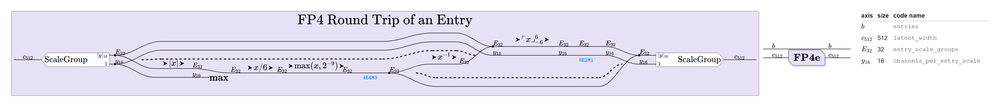

In [7]:
entry_round_trip = quantised_text_only_model.part_named('FP4e', UNQUANTISED)

await figures.show(
    entry_round_trip,
    'The FP4 round trip of one compressed entry. The channels are viewed in groups of '
    'sixteen, the largest magnitude of each group gives the scale, which is rounded '
    'through E4M3, and each channel is divided by the scale, clamped to the range of '
    'E2M1, cast to four bits, cast back and multiplied by the scale.',
    width=1700, sub_blocks=figures.SubBlocks.EVERY_BODY, settings=FIGURES)

## The lightning indexer and the Top-512 selection

A layer that attends over compressed entries does not read every entry. The lightning indexer scores every entry a query has reached, and a Top-512 keeps the best of them ([L515](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L515), [L555-L557](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L555-L557), [L578-L580](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L578-L580)). The indexer has 32 heads of width 128. Its query is projected from the same 1,280-wide low rank as the query of the attention, and its keys are projected from the compressed entries at the layer that compresses them.

Each of the 32 heads scores a query against an entry, and each score is rectified. The rectified scores are summed under a weight read off the 5,120-wide hidden state by the released `weights_proj`, one number per token and per head, multiplied by $(\lvert d \rvert\, \lvert i \rvert)^{-1/2}$ ([L513](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L513), [L555](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L555)). The scoring reads one query at a time, so it is one box computed once per token.

A query reaches an entry once it has passed the last token of the entry. The released code computes the number of entries visible to query $i_{x}$ as $\lfloor (i_{x} + 1) / \lvert a \rvert \rfloor$ and fills the score of every entry at or past that count with $-\infty$ ([L563-L565](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L563-L565), [L567](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L567)). The expression states the same causality with two reads. A back view reads the keys at $i_{b} - i_{r}$, the key $i_{r}$ entries back from entry $i_{b}$, so a slot that counts past the first entry reads the universal unit. A covariant view then writes the slots of each entry onto the queries that entry serves, at $i_{x} = \lvert a \rvert\, i_{b} + i_{a} + \lvert a \rvert - 1$, and the slots leave as `r|x`, holding a value where $i_{x} - \lvert a \rvert\, i_{r} - (\lvert a \rvert - 1) \geq 0$. A distance $i_{r}$ for query $i_{x}$ names the entry $\lfloor (i_{x} + 1) / \lvert a \rvert \rfloor - 1 - i_{r}$ of the released code.

The back view is a causal read, and in the CausalSlide it leaves the indexer box. The back view of the entries leaves the gather box in the same way and stands where the entries are dropped onto the tape. In the decoder the keys are dropped onto the tape as well, and their back view stands at the dropped keys. In the encoder the keys are not published, and their back view moves past the key projection, its normalisation, its rotation and its FP4 round trip to the compressed entries, so those run once per entry and distance.

The Top-512 over the scores stands in the attention mode, outside the indexer box. It returns the distances of the chosen entries and no score, and a gather reads the compressed entry at each distance.

The lightning indexer of the encoder, with the body of each box beside it. The query is projected from the low rank, turned by YaRN and rounded through the FP4 round trip of the indexer. The keys arrive read back from each entry, the merge writes the slots of each entry onto every query whose newest reachable entry it is, and the scoring box rectifies the scores of the 32 heads and combines them under a weight per token and head.


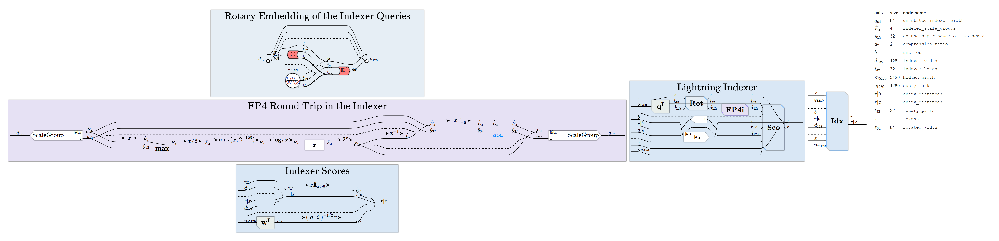

In [8]:
indexer = quantised_text_only_model.part_named('Idx', UNQUANTISED)

await figures.show(
    indexer,
    'The lightning indexer of the encoder, with the body of each box beside it. The '
    'query is projected from the low rank, turned by YaRN and rounded through the FP4 '
    'round trip of the indexer. The keys arrive read back from each entry, the merge '
    'writes the slots of each entry onto every query whose newest reachable entry it '
    'is, and the scoring box rectifies the scores of the 32 heads and combines them '
    'under a weight per token and head.',
    width=1850, settings=FIGURES)

## The hierarchical candidate pool

Scoring every reachable entry takes one score per entry and per query, and that number grows with the context. Layer 20, the first layer of the decoder, computes the candidate pool once. Beside its own Top-512 it takes the best score in each block of 8 consecutive distances, keeps the 2,048 best blocks, and publishes the 16,384 distances those blocks cover on the tape slot $\mathrm{pool}$ ([L583-L609](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L583-L609)). Each Reindex layer below it reads the scores of its indexer at those distances alone.

Splitting the distances into blocks of 8 is affine and is drawn as a view. The best score of each block is its maximum, and the Top-2048 over the blocks returns the kept block numbers alone. Putting a kept block back onto the distances applies the block split to its number at every offset, $\mathrm{pos}[i_{x}, i_{p}, i_{u}] = \lvert u \rvert\, \mathrm{idx}[i_{x}, i_{p}] + i_{u}$, and a covariant view lays the 2,048 by 8 results along the candidate axis $C$. The pool is one box computed once per token, and it returns positions.

The block that holds a query's newest reachable entry is partly filled unless the count of reachable entries is a multiple of 8, so an older full block can have a higher score. The released code sets the score of that block to $+\infty$ before the selection, so the block stays in the pool ([L597-L607](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L597-L607)). The expression counts blocks back from the query's newest reachable entry, so the pinned block is block 0 for every query, and a covariant view writes $+\infty$ at block 0 to be added to the block scores.

The candidate pool. The distances are split into blocks of eight and each block is scored by its best distance, positive infinity is added at block 0 so that the newest block is kept, the Top-2048 returns the kept block numbers, and the merge applies the block split to each of them at every offset and lays the 2048 by 8 distances along one axis.


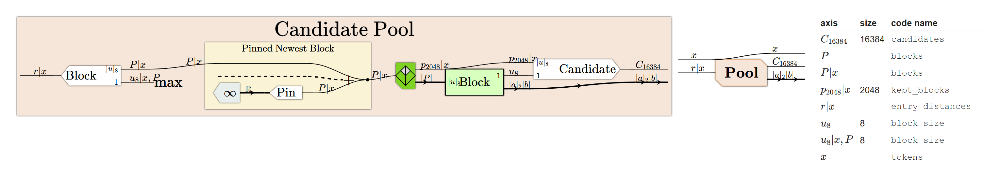

In [9]:
candidate_pool = quantised_text_only_model.part_named('Pool', UNQUANTISED)

await figures.show(
    candidate_pool,
    'The candidate pool. The distances are split into blocks of eight and each block is '
    'scored by its best distance, positive infinity is added at block 0 so that the '
    'newest block is kept, the Top-2048 returns the kept block numbers, and the merge '
    'applies the block split to each of them at every offset and lays the 2048 by 8 '
    'distances along one axis.',
    width=1400, settings=FIGURES)

## The three compressed sparse attention modes

Every layer from 2 upward reads a 128-token sliding window and a set of selected compressed entries under one softmax. The window latents and the selected latents are laid end to end along one slot axis in front of the attention core, so one softmax runs over the 128 window slots, the 512 selected slots and the sink together. Every mode computes its own query, its own window latents and its own output projection from its own hidden state, and the three modes differ in which wires reach them.

A Full layer computes its own compressed entries, its own indexer keys, its own scores and a fresh Top-512, and publishes all of them. Layers 2, 8, 14 and 20 are Full. A Reindex layer takes the entries, the keys and the candidate pool from layer 20, scores the entries with its own indexer query, reads its scores at the 16,384 distances of the pool and selects a fresh Top-512 among them. Layers 24, 28, 32 and 36 are Reindex. A Reuse layer takes the entries and the latest selection from a layer before it and runs no indexer at all, and every other layer from 2 upward is Reuse. The model writes the Full mode at three sites, the Reindex mode at one and the Reuse mode at four.

Each mode is boxed together with the grabs and the drops it performs. Seven slots carry the values between layers: the compressed entries and the selection of each encoder group, the entries, the indexer keys, the candidate pool and the selection of the decoder, and the token identifiers read by Engram. A slot written inside a repeated group and read inside the same iteration carries the counter of that group, so the three encoder groups write three members of one slot ([L1166-L1176](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1166-L1176)).

Full mode in the encoder. The compressor, the indexer keys, the indexer and a fresh Top-512 all sit inside the layer, and the compressed entries and the selection are dropped onto the two tape slots read by the Reuse layers of the same group.


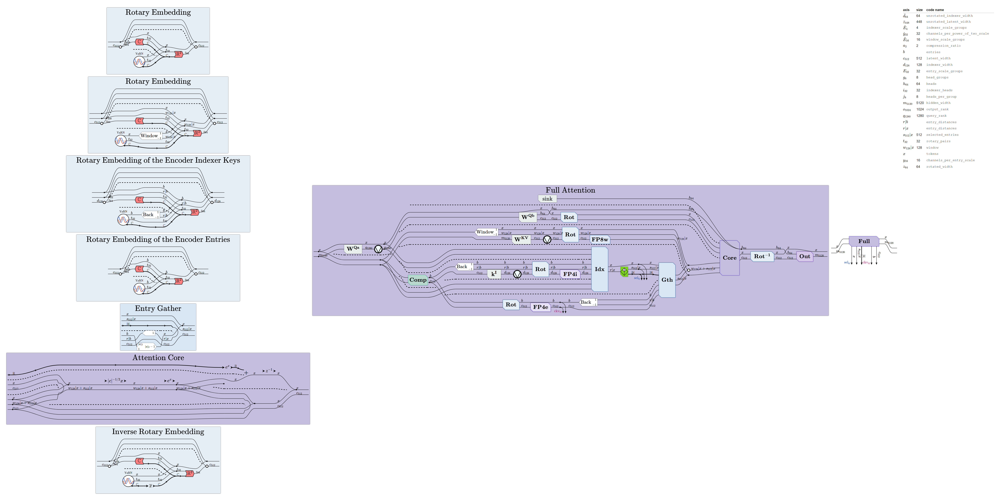

Reindex mode. The entries, the keys and the pool are grabbed from the slots written by the first layer of the decoder, the scores of the indexer are read at the distances of the pool, and the selection is the one array dropped by the mode.


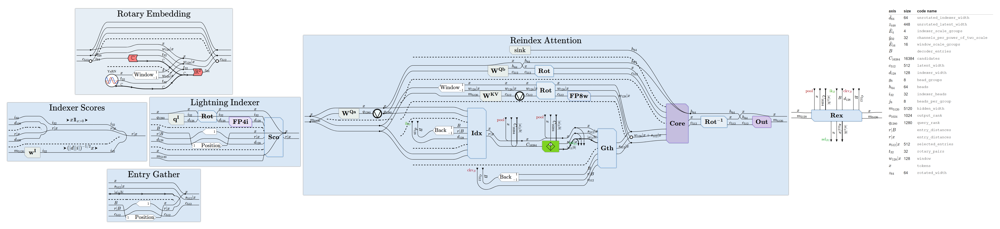

Reuse mode. The compressed entries and the Top-512 are grabbed from their slots, and the layer computes its own query, its own window latents and its own output projection.


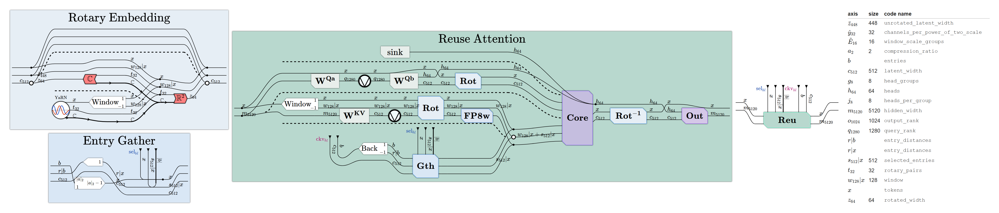

In [10]:
full_attention = quantised_text_only_model.part_named('Full', UNQUANTISED)
reindex_attention = quantised_text_only_model.part_named('Rex', UNQUANTISED)
reuse_attention = quantised_text_only_model.part_named('Reu', UNQUANTISED)

await figures.show(
    full_attention,
    'Full mode in the encoder. The compressor, the indexer keys, the indexer and a fresh '
    'Top-512 all sit inside the layer, and the compressed entries and the selection are '
    'dropped onto the two tape slots read by the Reuse layers of the same group.',
    width=2000, settings=FIGURES)

await figures.show(
    reindex_attention,
    'Reindex mode. The entries, the keys and the pool are grabbed from the slots written '
    'by the first layer of the decoder, the scores of the indexer are read at the '
    'distances of the pool, and the selection is the one array dropped by the mode.',
    width=2000, settings=FIGURES)

await figures.show(
    reuse_attention,
    'Reuse mode. The compressed entries and the Top-512 are grabbed from their slots, and '
    'the layer computes its own query, its own window latents and its own output '
    'projection.',
    width=1600, settings=FIGURES)

## The mixture of experts and its routing

Every second sublayer is a mixture of experts. The router scores all 384 routed experts from the hidden state of the token and keeps six ([L822-L826](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L822-L826)). The score is the square root of the softplus of the logit divided by a temperature $\tau$, which the released configuration sets to one ([L811](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L811)). The router is one box inside the mixture.

The selection and the gates read two copies of the scores. One copy has a learned correction bias added to it and chooses the six experts. The other stays unbiased and is read at the slots chosen by the biased copy, which the released code writes as `scores.gather(1, (scores + bias).topk(k)[1])`. The bias therefore changes which six experts run and never scales the output of one of them. The six gates are divided by their sum plus $\varepsilon_{\mathrm{r}}$ and multiplied by the route scale of 1.5.

Each expert is a SwiGLU of hidden width 2,304. It holds a gate projection, an up projection, the product of the SiLU of the gate branch with the up branch, and a down projection. The up branch is clamped to $[-\lambda, \lambda]$ and the gate branch is clamped from above at $\lambda$, and the released $\lambda$ is 10 ([L843-L848](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L843-L848)). One shared expert of the same width runs at every token beside the six routed ones.

The down projection of the routed experts produces the expert axis, and a diagonal view keeps the expert of each slot, so a token goes in and one 5,120-wide vector per chosen slot comes out. The gates are applied to the outputs of the experts in one contraction over the six slots, because $\sum_{i_{k} \in k} W[i_{k}]\, (g[i_{k}]\, h[i_{k}])$ equals $\sum_{i_{k} \in k} g[i_{k}]\, (W[i_{k}]\, h[i_{k}])$. Every operation of the mixture is the same map at every token, so the mixture is one box computed once per token.

The mixture of experts of one token. The Gate box runs from the router weight to the six normalised gates, each routed expert is a clamped SwiGLU whose down projection is diagonalised at its own expert, the gates meet the expert outputs in one contraction over the six slots, and the shared expert is added.


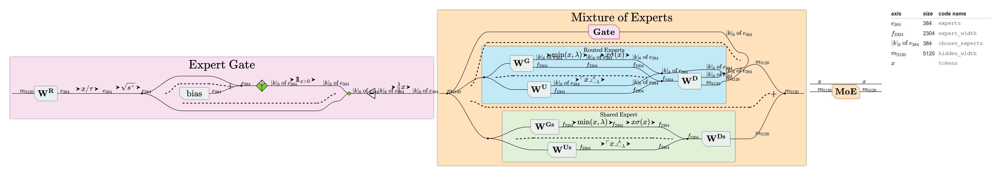

In [11]:
mixture = quantised_text_only_model.part_named('MoE', UNQUANTISED)

await figures.show(
    mixture,
    'The mixture of experts of one token. The Gate box runs from the router weight to the '
    'six normalised gates, each routed expert is a clamped SwiGLU whose down projection '
    'is diagonalised at its own expert, the gates meet the expert outputs in one '
    'contraction over the six slots, and the shared expert is added.',
    width=1800, settings=FIGURES)

## The Engram modules

Engram adds a gated lookup to the residual before layer 1 and before layer 14 ([L1263](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1263)). The identifiers of the last four tokens are mapped to identifiers of their normalised text through a fixed table built from the tokenizer, so that `The`, `the` and `THE` hash alike, and the map has 99,092 distinct results. An n-gram is a run of the last two, three or four of those identifiers, and a hash sends each n-gram to one row of a table of about 384 million rows ([engram.py L64-L83](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/engram.py#L64-L83), [engram.py L102-L118](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/engram.py#L102-L118), [engram.py L164-L184](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/engram.py#L164-L184)). Eight hash heads give each n-gram eight rows, so the rows read for one n-gram seldom collide in every head at once. The tables of layers 1 and 14 hold 384,006,168 and 384,016,682 rows.

The hash of layer $l$ multiplies each identifier by a fixed multiplier, combines the products of one n-gram with the exclusive or, takes the remainder after division by a prime, and adds the offset that keeps the 24 ranges of rows apart. For the identifiers $\tilde{c}$ it is $\mathrm{hash}_{l}(\tilde{c})[i_{G}, i_{K}] = \big( \bigoplus_{i_{L} \in L,\; i_{L} \leq i_{G} + 1} \alpha_{l}[i_{L}]\, \tilde{c}[i_{L}] \big) \bmod p_{l}[i_{G}, i_{K}] + o_{l}[i_{G}, i_{K}]$. The hash is written out over two fixed arrays, the exclusive or, the remainder and one cast into a row number.

The rows are looked up and projected into one key per residual stream and one value shared by the streams ([L296-L326](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L296-L326)). The gate of a stream is the normalised dot product of the stream with its normalised key, passed through a signed square root and a sigmoid, and the gated value is added to every stream ([L328-L365](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L328-L365)). Each layer carries multipliers, primes, a table and weights of its own, and the subscript of every name states the layer it belongs to.

The lookback that reads the last four identifiers is a causal read. In the CausalSlide it reads the identifiers grabbed from the tape, and the token map runs on every slot of the lookback.

The Engram module before layer 1. The token identifiers are grabbed from the tape and read back four tokens, the token map is a table lookup returning an identifier, the n-gram hash is written out over the integer operators, the 24 rows are looked up and projected into keys and a value, and the gate scales the value into every stream.


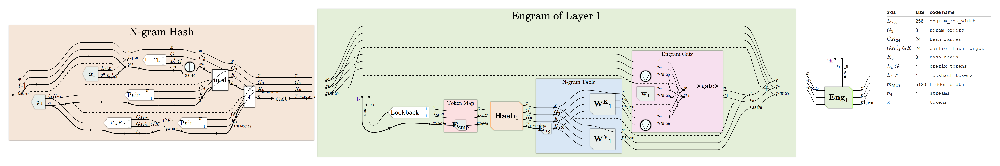

In [12]:
engram = quantised_text_only_model.part_named('Eng{1}', UNQUANTISED)

await figures.show(
    engram,
    'The Engram module before layer 1. The token identifiers are grabbed from the tape '
    'and read back four tokens, the token map is a table lookup returning an identifier, '
    'the n-gram hash is written out over the integer operators, the 24 rows are looked '
    'up and projected into keys and a value, and the gate scales the value into every '
    'stream.',
    width=2000, settings=FIGURES)

## The forty layers and the layer plan

The released `kv_source_layer_ids` and `index_source_layer_ids` give the layer plan ([config.json L26-L28](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/config.json#L26-L28), [config.json L36-L41](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/config.json#L36-L41)). Layers 0 and 1 run the sliding window alone. Layers 2 to 19 are the causal encoder at compression ratio two, in three groups of six, each headed by a Full layer with five Reuse layers after it. Layers 20 to 39 are the decoder at ratio one. Layer 20 is Full and is the source of the candidate pool, layers 24, 28, 32 and 36 are Reindex, and every other decoder layer is Reuse. The counts add to $2 + 3 \times (1 + 5) + (1 + 3) + 4 \times (1 + 3) = 40$.

A group of layers that repeats is written as one block at that repetition. Engram stands before layer 1 and before layer 14, and layer 14 heads the third encoder group. The two sliding-window layers are therefore written with Engram between them, and the encoder as a block at repetition two, Engram, and the third group written alone. The four Reindex groups are one block at repetition four.

Each layer is an attention sublayer and a mixture sublayer, so the figure below holds forty layers and eighty sublayers. The residual and the collapse vector are the only wires between the boxes, and every slot is drawn leaving the box that writes it and entering each box that reads it.

The whole model, drawn with the body of every box left out. The embedding, two sliding-window layers with Engram between them, the encoder groups at repetition two, Engram, the third encoder group, the Full layer of the decoder with its three Reuse layers, the four Reindex groups at repetition four, the collapse of the four streams and the output probabilities.


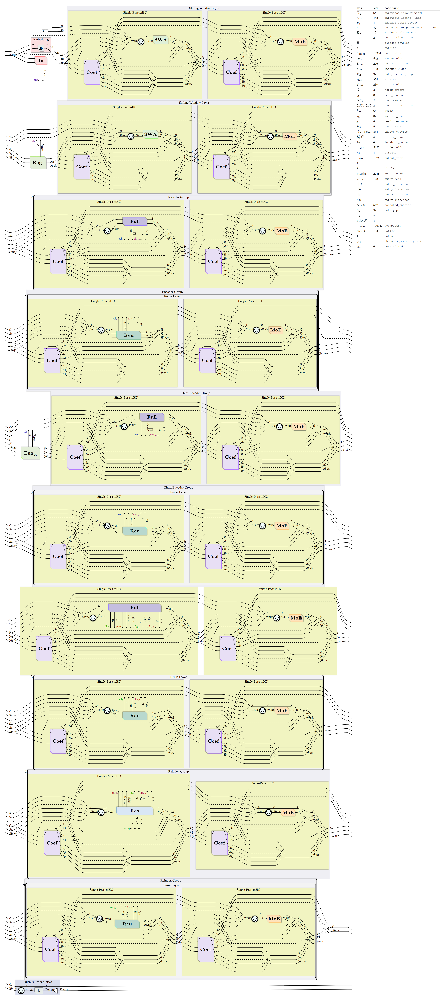

In [13]:
await figures.show(
    UNQUANTISED,
    'The whole model, drawn with the body of every box left out. The embedding, two '
    'sliding-window layers with Engram between them, the encoder groups at repetition '
    'two, Engram, the third encoder group, the Full layer of the decoder with its three '
    'Reuse layers, the four Reindex groups at repetition four, the collapse of the four '
    'streams and the output probabilities.',
    width=1605, sub_blocks=figures.SubBlocks.NO_BODIES, settings=FIGURES)

## The output probabilities

The four streams are collapsed into one hidden state by the collapse vector predicted by the last sublayer, the hidden state is normalised, and one weight maps it to a logit for each of the 129,280 vocabulary entries. A softmax over the vocabulary gives the probability of every next token ([L1269](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1269), [L1012](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1012), [L1291](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1291)).

The tail of the model. The four streams are collapsed under the last collapse vector, the RMSNorm is applied, the output head maps onto the vocabulary and the softmax gives the probabilities.


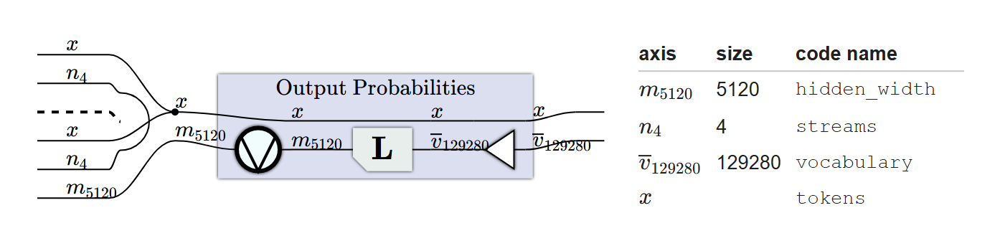

In [14]:
tail = quantised_text_only_model.part_after_the_layers(UNQUANTISED)

await figures.show(
    tail,
    'The tail of the model. The four streams are collapsed under the last collapse '
    'vector, the RMSNorm is applied, the output head maps onto the vocabulary and the '
    'softmax gives the probabilities.',
    width=1000, sub_blocks=figures.SubBlocks.EVERY_BODY, settings=FIGURES)

## The quantisations of the released code

A quantisation is the number format a value is held in, together with the size of that format in bits. The released code follows four rules. A tensor passed from one module or kernel to the next is held in BF16. Arithmetic inside a module that upcasts on entry, and inside every kernel, runs in FP32. An activation is rounded in one place, in front of a projection whose weight is FP8 or FP4, by the rounding kernel that the projection calls. Everything else computes at the quantisation carried by its operands and promotes to the one with more bits where they differ, as PyTorch does.

The rounding kernel cuts the channels of a row into groups of 32. It rounds the largest magnitude of each group over 448 up to a power of two to give the scale of the group, and rounds each channel divided by that scale to E4M3. The wire after the kernel carries the E4M3 elements and the scales, and the Microscaling specification of the Open Compute Project names that format MXFP8. A weight held in FP8 is E4M3 with one UE8M0 scale per block of 32 rows by 32 channels, and a routed expert is MXFP4, which is E2M1 elements with one UE8M0 scale per 32 channels.

An index carries an integer format. The token identifiers and the token map of Engram are held in INT64, the `int64` of the released code. The candidate pool and each indexer convert their positions to INT32, the format the attention kernel declares for the positions it reads, so the pool and the two selection slots carry INT32.

Four boxes depart from the pattern. The attention kernel reads BF16 queries and latents into FP32 accumulators and casts the probabilities to BF16 for the product with the values. The scoring of the indexer and the candidate pool are eager code over BF16 tensors that never upcasts. The router and the mixing coefficients hand FP32 on. The table gives the policy with the released lines read for each row.

In [15]:
display(Markdown(quantised_text_only_model.policy_table()))

| quantisation | what it applies to | released lines |
|---|---|---|
| BF16, 16 bits, packed 2 to a word | every tensor returned by a module or a kernel: the result of a matrix multiply, the result of an RMSNorm, the residual stream written back at the end of a sublayer, and the value returned by every box unless a row below names another | [inference/kernel.py L299](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L299), [inference/kernel.py L583](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L583), [inference/model.py L293](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L293), [inference/model.py L960](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L960), [inference/model.py L966](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L966), [inference/model.py L904](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L904), [inference/model.py L365](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L365), [inference/model.py L485](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L485), [inference/generate.py L118](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/generate.py#L118) |
| FP32, 32 bits | the arithmetic inside a module upcasting on entry and inside every kernel: the router, the SwiGLU of an expert, the mixing coefficients, the gate of Engram, the pooling of a compressor, the logits, the attention kernel and the rounding kernels of the caches | [inference/model.py L811](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L811), [inference/model.py L843-L848](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L843-L848), [inference/model.py L952-L954](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L952-L954), [inference/model.py L355-L365](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L355-L365), [inference/model.py L464](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L464), [inference/model.py L1012](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1012), [inference/kernel.py L51](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L51), [inference/kernel.py L135](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L135), [inference/kernel.py L339-L385](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L339-L385) |
| MXFP8: E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 channels | the operand of a projection whose weight is FP8 or FP4, which is the one place the released code rounds an activation: the rounding kernel writes the E4M3 elements and one UE8M0 scale per 32 channels, and the GEMM multiplies its FP32 accumulator by that scale and the scale of the weight | [inference/model.py L181-L206](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L181-L206), [inference/kernel.py L41-L96](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L41-L96), [inference/kernel.py L256-L269](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L256-L269), [inference/kernel.py L544-L553](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L544-L553) |
| MXFP8: E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 channels | the n-gram tables of Engram, whose rows reach the key and value projections with no cast, because the released lookup multiplies a row by its scales into BF16 and the projection rounds it back with the same groups of 32, which changes no value | [inference/model.py L307-L310](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L307-L310), [inference/model.py L316-L321](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L316-L321), [inference/model.py L353](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L353) |
| FP32, 32 bits | the values returned by the router and the mixing coefficients, multiplied in FP32 by the expert weights and the stream mixes, and the probabilities returned by the model | [inference/model.py L811-L827](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L811-L827), [inference/model.py L850](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L850), [inference/kernel.py L414-L419](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L414-L419), [inference/model.py L959](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L959), [inference/model.py L965](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L965), [inference/model.py L1291](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1291) |
| BF16, 16 bits, packed 2 to a word | the queries and the cached latents read by the attention kernel, and the probabilities cast down by it for the product with the values, while its two accumulators stay in FP32 | [inference/kernel.py L329-L330](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L329-L330), [inference/kernel.py L339](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L339), [inference/kernel.py L377](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L377), [inference/kernel.py L385](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L385) |
| BF16, 16 bits, packed 2 to a word | the indexer scores from end to end: the einsum of the queries against the keys, the rectification, and the sum under the head weights. The keys and queries were rounded to four bits and written back as BF16, and the key cache is a BF16 buffer, so the reference implementation scores in BF16 and takes neither the smaller cache nor the faster scoring that the four-bit form allows | [inference/model.py L521-L525](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L521-L525), [inference/model.py L546](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L546), [inference/model.py L552](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L552), [inference/model.py L555-L557](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L555-L557) |
| MXFP4: E2M1, 4 bits, packed 8 to a word, with one UE8M0 scale per 32 channels | the gate, up and down projections of a routed expert, with one UE8M0 scale per 32 channels along the contracted axis | [inference/model.py L872-L880](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L872-L880), [config.json L106](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/config.json#L106), [inference/model.py L219-L224](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L219-L224) |
| E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | every weight declared by the released code at its default: the query, key and second output projections of the attention, the indexer queries, the shared expert, and the key and value projections of Engram, with one UE8M0 scale per block of 32 rows by 32 channels | [inference/model.py L26](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L26), [inference/model.py L1191](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1191), [inference/model.py L640-L650](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L640-L650), [inference/model.py L514](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L514), [inference/model.py L887](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L887), [inference/model.py L345](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L345), [inference/model.py L225-L232](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L225-L232) |
| BF16, 16 bits, packed 2 to a word | the token embedding, the first output projection, written out of its FP8 file form by the conversion, and the indexer key and head-weight projections | [inference/model.py L166](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L166), [inference/convert.py L157-L173](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/convert.py#L157-L173), [inference/model.py L787](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L787), [inference/model.py L518](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L518), [inference/model.py L515](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L515) |
| FP32, 32 bits | the mixing projections and the compressor projections, the router weight and the stream weights of Engram, which are BF16 in the file and read through `.float()`, the correction bias, the sink logit, and the output head | [inference/model.py L940-L946](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L940-L946), [inference/model.py L446-L448](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L446-L448), [inference/model.py L805-L811](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L805-L811), [inference/model.py L347-L356](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L347-L356), [inference/model.py L806](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L806), [inference/model.py L639](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L639), [inference/model.py L1006](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1006) |
| BF16, 16 bits, packed 2 to a word | the compressed entries, the indexer keys and the window latents in the caches, which hold the value returned by a rounding kernel called in place: each group of channels is divided by its scale, rounded through E2M1 or E4M3 and multiplied by its scale again, so the cache holds BF16 numbers carrying the rounding and keeps no scale beside them | [inference/model.py L705-L707](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L705-L707), [inference/model.py L546](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L546), [inference/model.py L758-L761](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L758-L761), [inference/kernel.py L81-L86](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L81-L86), [inference/kernel.py L167-L172](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L167-L172), [inference/convert.py L13-L15](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/convert.py#L13-L15) |
| INT64, 64 bits | every index: the token identifiers on arrival, the token map and the n-gram hash of Engram, the positions picked by a top-k selection, and the routing of the experts | [inference/generate.py L51-L53](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/generate.py#L51-L53), [inference/engram.py L64-L83](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/engram.py#L64-L83), [inference/engram.py L155-L157](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/engram.py#L155-L157), [inference/model.py L579](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L579), [inference/model.py L822](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L822) |
| INT32, 32 bits | the positions returned by the candidate pool, and the positions read by the attention kernel, which the indexer converts before handing them over | [inference/model.py L425-L426](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L425-L426), [inference/model.py L580](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L580), [inference/model.py L1029](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1029), [inference/kernel.py L333](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L333) |

A weight has no wire, so no label states its quantisation. The table below gives the quantisation at which the released model reads each of its 33 weights, and the quantisation held in the file where the two differ.

In [16]:
display(Markdown(quantised_text_only_model.weight_table()))

| weight | read quantisation | quantisation in the file |
|---|---|---|
| $E$ | BF16, 16 bits, packed 2 to a word | the same |
| $E\mathrm{cmp}$ | INT64, 64 bits | the same |
| $E\mathrm{ng}{14}$ | MXFP8: E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 channels | the same |
| $E\mathrm{ng}{1}$ | MXFP8: E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 channels | the same |
| $H0$ | FP32, 32 bits | the same |
| $H1$ | FP32, 32 bits | the same |
| $H2$ | FP32, 32 bits | the same |
| $L$ | FP32, 32 bits | BF16, 16 bits, packed 2 to a word |
| $W^{C}$ | FP32, 32 bits | BF16, 16 bits, packed 2 to a word |
| $W^{Ds}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{D}$ | MXFP4: E2M1, 4 bits, packed 8 to a word, with one UE8M0 scale per 32 channels | the same |
| $W^{Gs}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{G}$ | MXFP4: E2M1, 4 bits, packed 8 to a word, with one UE8M0 scale per 32 channels | the same |
| $W^{KV}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{K}{14}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{K}{1}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{Oa}$ | BF16, 16 bits, packed 2 to a word | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block |
| $W^{Ob}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{Qa}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{Qb}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{R}$ | FP32, 32 bits | BF16, 16 bits, packed 2 to a word |
| $W^{Us}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{U}$ | MXFP4: E2M1, 4 bits, packed 8 to a word, with one UE8M0 scale per 32 channels | the same |
| $W^{V}{14}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{V}{1}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $W^{Z}$ | FP32, 32 bits | the same |
| $\mathrm{bias}$ | FP32, 32 bits | the same |
| $\mathrm{sink}$ | FP32, 32 bits | the same |
| $\mathrm{w}{14}$ | FP32, 32 bits | BF16, 16 bits, packed 2 to a word |
| $\mathrm{w}{1}$ | FP32, 32 bits | BF16, 16 bits, packed 2 to a word |
| $k^{I}$ | BF16, 16 bits, packed 2 to a word | the same |
| $q^{I}$ | E4M3, 8 bits, packed 4 to a word, with one UE8M0 scale per 32 by 32 block | the same |
| $w^{I}$ | BF16, 16 bits, packed 2 to a word | the same |

The policy is written onto the model by a pass that gives every wire holding a number a quantisation and places a conversion, called a cast, wherever an operation needs a quantisation its operand does not carry. The quantised model holds 190 casts, counted as written operations, so a cast inside a repeated block is counted once. Every one of them changes the quantisation of its operand. Twenty-five casts round BF16 to MXFP8, each in front of a projection whose weight is FP8 or FP4. Seventy-three read BF16 into FP32, which changes no value, and seventy-nine round FP32 to BF16. Two round into E2M1 and two into E4M3 inside the round trips of the caches, and four read a rounded value back into FP32. Five convert positions from INT64 to INT32. The n-gram tables of Engram are MXFP8, and their rows reach the key and value projections with no cast, because a row already carries its scale.

In [17]:
for pair, count in sorted(quantised_text_only_model.cast_counts().items()):
    print(f'{pair[0]:>12} -> {pair[1]:<6} {count}')

        BF16 -> FP32   73
        BF16 -> MXFP8  25
        E2M1 -> FP32   2
        E4M3 -> FP32   2
        FP32 -> BF16   79
        FP32 -> E2M1   2
        FP32 -> E4M3   2
       INT64 -> INT32  5


The figure below draws the sliding-window attention of the quantised model. Every wire carries its quantisation in front of its axes, and a cast draws no glyph. The format written by a cast is coloured blue on the wire after it. A label states in front of the format how many values a 32-bit word holds, as $2\mathtt{BF16}$.

The sliding-window attention of the quantised model, with the body of each box beside it. The hidden state is rounded once to MXFP8, and the query projection and the window both read the rounded state, so the key-value projection of every slot reads MXFP8. The rotation computes in FP32, the latent passes through its FP8 round trip, and the attention core reads BF16 into FP32 accumulators.


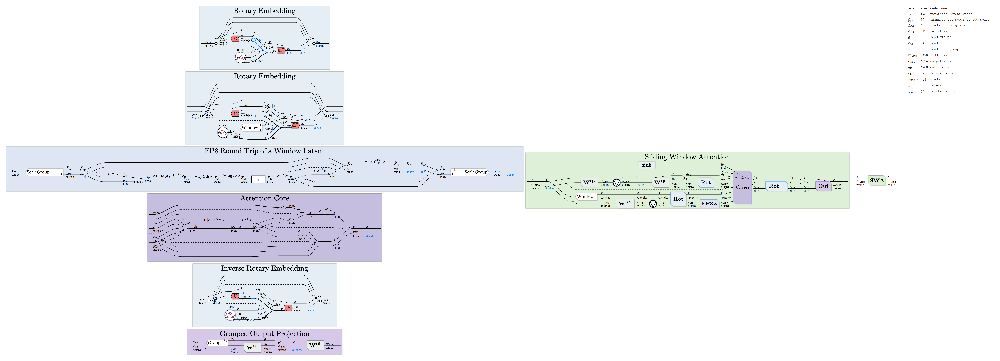

In [18]:
quantised_window = quantised_text_only_model.part_named('SWA', QUANTISED)

await figures.show(
    quantised_window,
    'The sliding-window attention of the quantised model, with the body of each box '
    'beside it. The hidden state is rounded once to MXFP8, and the query projection and '
    'the window both read the rounded state, so the key-value projection of every slot '
    'reads MXFP8. The rotation computes in FP32, the latent passes through its FP8 round '
    'trip, and the attention core reads BF16 into FP32 accumulators.',
    width=2500, sub_blocks=figures.SubBlocks.EVERY_BODY, settings=QUANTISED_FIGURES)

## Differences between the expression and the released code

The expression computes what the released code computes except at the points below, each of which follows from writing the model over the whole prompt at once.

- The compressor reads every token of the prompt at once. In decode the released compressor keeps the values and the gate logits of an unfinished group in two buffers and returns an entry only at the step that completes the group ([L476-L485](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L476-L485)).
- The gate of a chosen expert whose biased score is at or below zero is zero in the expression, because the gates are read through the indicator of a positive biased score, and is the unbiased score in the released code.
- The lookback of the n-gram hash reads the universal unit at a slot that reaches before the first token, and the released code writes a pad identifier into such a slot, so the two differ at the first three tokens of a sequence.
- The pin of the candidate pool keeps the eight newest entries, and the released code pins the block of the newest entry, which holds one to eight entries, because the two number the blocks differently.

## The quantised and unquantised variants of the interactive page

The last cell writes the model to one HTML file that opens with no server and no network. The page holds two variants in one group named Decode, and a selector above the figure switches between them. Resting the pointer on a block or an operator opens an inspection box with its title, a description, the released lines it expresses, and its body or its expansion.

The Quantised variant draws the quantised model, with a quantisation on every wire. The box over a cast names the quantisation read by the cast and the quantisation written by it, and the box over a weight names the quantisation at which the released model reads the weight. The Unquantised variant draws the model in the reals, with blocks of the same titles and the same explanations, and no box of it names the quantisation of a weight.

Taking every quantisation off the quantised model, and deleting every cast between two quantisations of one value, gives back the operations of the model in the reals. The two hold the same operations counted by kind apart from the casts, carry the same datatypes on their wires apart from the E2M1 and E4M3 channels inside the round trips, and have the same body in every box apart from the three round trips of the caches.

The Unquantised variant still performs three roundings. It rounds every window latent through FP8, every key and query of the indexer through FP4, and every compressed entry through FP4, as the released code does. The released code performs those roundings in place on the values it computes with, so the attention reads rounded latents and entries and the indexer scores rounded keys and queries. The roundings therefore change what the model computes, and the model in the reals keeps them so that it computes what the released code computes. No other wire of the Unquantised variant carries a quantisation.

Taking the quantisations off the quantised model deletes those three roundings as well, because each of their casts reads one quantisation of a channel into another. The round trip then divides a group by its scale and multiplies it back with no rounding in between. The Unquantised variant is therefore drawn from the model in the reals, as a term of its own with its own tables. A variant derived by taking the quantisations off the Quantised variant would draw the round trips without their rounding, under titles and descriptions that say they round, and would keep the quantisation of every weight in the box over it.

In [19]:
DECODE = notebook_diagrams.PageVariantGroup('decode', 'Decode')

await notebook_diagrams.show_page_variants(
    (notebook_diagrams.PageVariant(
         identifier='decode-quantised', group=DECODE, title='Quantised',
         detail='every array at the number format of the released inference code',
         term=QUANTISED, settings=QUANTISED_PAGE),
     notebook_diagrams.PageVariant(
         identifier='decode-unquantised', group=DECODE, title='Unquantised',
         detail='the same arithmetic in the reals, keeping the rounding of the three caches',
         term=UNQUANTISED, settings=UNQUANTISED_PAGE)),
    'DeepSeek-V4.1-Flash with its Quantised and Unquantised variants, with the legend of '
    'its axes and an inspection box over every block and every operator.',
    settings=QUANTISED_PAGE, slug='DeepSeekV41Flash', initial='decode-quantised')

DeepSeek-V4.1-Flash with its Quantised and Unquantised variants, with the legend of its axes and an inspection box over every block and every operator.


(written to notebooks/website/output/modern/DeepSeekV41Flash/)


## The released code of DeepSeek-V4.1-Flash

The released code is the git repository `deepseek-ai/DeepSeek-V4.1-Flash` on Hugging Face, read at commit `dba1be0a40aa` on 2026-09-11. The model is `inference/model.py`, the fused kernels are `inference/kernel.py`, the layer plan is `inference/config.json`, and the n-gram hash is `inference/engram.py`. Every block of the model carries the links of its own mechanism, so an inspection box opened over a block on the page reaches the lines it expresses.

| mechanism | released code | lines |
| --- | --- | --- |
| Embedding and output head | `Transformer.embed` and `Transformer.head` | [L174](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L174), [L1253](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1253), [L1012](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1012), [L1291](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1291) |
| The four residual streams | the `repeat` over `hc_mult` | [L1257-L1258](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1257-L1258) |
| The first collapse vector | `make_identity_pre_mix` | [L1159-L1163](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1159-L1163) |
| Single-Pass mHC | `Block`, the `hc_split_sinkhorn` call and `hc_pre` | [L907-L915](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L907-L915), [L938](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L938), [L955-L959](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L955-L959), [kernel.py L427](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L427), [kernel.py L436-L443](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L436-L443), [kernel.py L450-L458](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L450-L458), [kernel.py L465](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L465) |
| Sliding window | `get_window_topk_idxs` and `Attention._window_kv` | [L410-L424](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L410-L424), [L700-L720](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L700-L720) |
| Attention sink | `attn_sink`, passed to `sparse_attn` | [L639](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L639), [L780](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L780), [kernel.py L392](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L392) |
| Empty slots read by the kernel | `sparse_attn` gives a $-1$ slot a zero key and a score of $-\infty$ | [kernel.py L362-L364](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L362-L364) |
| The score scales | `softmax_scale` of the attention and of the indexer | [L651](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L651), [L513](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L513), [L555](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L555) |
| The rotary embedding and YaRN | `precompute_freqs_cis`, `apply_rotary_emb`, and the base of each layer | [L368-L406](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L368-L406), [L680-L687](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L680-L687), [L705-L706](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L705-L706), [L771-L772](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L771-L772), [L780-L781](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L780-L781), [config.json L29-L33](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/config.json#L29-L33), [config.json L51](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/config.json#L51) |
| Grouped output projection | `einsum("bsgd,grd->bsgr")` | [L787](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L787) |
| Compressor | `Compressor`, and the softmax-gated sum over each group | [L429](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L429), [L475](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L475), [L476-L485](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L476-L485) |
| The FP4 and FP8 round trips | `fp4_act_quant` and `act_quant`, called in place | [L707](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L707), [L758-L761](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L758-L761), [kernel.py L22-L37](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L22-L37), [kernel.py L158-L171](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/kernel.py#L158-L171) |
| Lightning indexer | `Indexer`: `weights_proj`, the rectified scores summed under the weights, and the Top-512 | [L515](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L515), [L555-L557](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L555-L557), [L578-L580](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L578-L580) |
| Causal visibility of compressed entries | `compress_lens`, and the $-\infty$ fill of every entry at or past it | [L563-L565](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L563-L565), [L567](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L567) |
| Candidate pool | `select_candidate_blocks` | [L583-L609](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L583-L609), [L597-L607](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L597-L607) |
| Router | `Gate`: the temperature, the biased Top-6, the unbiased gather, the normalisation and the route scale | [L811](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L811), [L817](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L817), [L822-L826](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L822-L826) |
| SwiGLU clamps | `Expert.forward` | [L843-L848](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L843-L848) |
| Engram | `engram.py`, and the module applied to the residual before layers 1 and 14 | [engram.py L64-L83](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/engram.py#L64-L83), [engram.py L102-L118](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/engram.py#L102-L118), [engram.py L164-L184](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/engram.py#L164-L184), [L296-L326](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L296-L326), [L328-L365](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L328-L365), [L1263](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1263) |
| The shared runtime | `SharedAttentionRuntime`, and its one instance | [L1166-L1176](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1166-L1176), [L1180](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/model.py#L1180) |
| The layer plan | `kv_source_layer_ids`, `index_source_layer_ids` and `compress_ratios` | [config.json L26-L28](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/config.json#L26-L28), [config.json L36-L41](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash/blob/dba1be0a40aa45a94ad051997016db3960a90277/inference/config.json#L36-L41) |
| The quantisations | the dtypes of `model.py`, the rounding kernels of `kernel.py`, and the checkpoint rewrite of `convert.py` | the policy table above |

The sources beside the code are the [model card](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash), the [release note](https://api-docs.deepseek.com/news/news260910/), and sections 2 and 3.2 of the technical report `DeepSeek_V41_Tech_Report.pdf`.